Note:

- Do not modify or change any hyperparameters or code other than what's blank.
- Focus on completing the missing parts accurately.



# Step 1 Import Libraries
Context:
- While printing a dataframe to avoid columns being missed out we can use "pd.set_option('display.max_columns', None)". This will display all the columns.

Hints: 
1. Import relevant function for label encoding from sklearn.preprocessing
2. Import relevant function to Min Max Scale from sklearn.preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import scipy.stats as stats
from IPython.display import display
import warnings
pd.set_option('display.max_columns', None)

# Step 2  Load dataset

Hints:
1. Use the read_csv method of pandas to load the csv file

In [2]:
df = pd.read_csv("../data/hotel.csv")

# Step 3 Exploratory Data Analysis (EDA)

## Display the top 5 rows of the dataframe
Hints:
1. use head method to get the top 5 rows of the dataframe 

In [3]:
df_head=df.head()
df_head

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Display the shape of the dataframe
Hints:

1. To get the shape of the DataFrame (number of rows and columns), you can use the shape attribute of the DataFrame df. 

In [4]:
df_shape=df.shape 
df_shape

(119390, 32)

## Information about data  
Hints:

1. To display information about the DataFrame, including data types and non-null values, you can use the info method.

In [5]:
df_info = df.info()
display(df_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

## Summary Statistics

Hints:
1. To get summary statistics of the DataFrame (e.g., mean, min, max) for numeric columns, you can use the describe method.

In [6]:
df_summary_numeric=df.describe()
df_summary_numeric

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Hints:

1. To get summary statistics of the DataFrame (e.g., unique, top, freq) for categorical columns, you can use the describe method with 'include='object''

In [7]:
df_summary_categorical=df.describe(include='object')
df_summary_categorical

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


## Null values count in each column of the DataFrame

Hints:
1. Use the isnull method followed by the sum method

In [8]:
null_count = df.isnull().sum()
print(null_count)

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## Check for duplicate rows and drop them

Hints:
1. Use duplicate method followed by sum method
2. If you find duplicates you can remove them using drop_duplicates method

In [9]:
count_of_duplicate_rows = df.duplicated().sum()
print(count_of_duplicate_rows)

31994


In [10]:
df = df.drop_duplicates()

In [11]:
count_of_duplicate_rows_2 = df.duplicated().sum()
print(count_of_duplicate_rows_2)

0


# Summary Statistics for continuous numerical columns by target feature categories
Context:
- This analysis helps us understand how the continous numerical columns(adr and lead_time) differ between the two categories(canceled and not canceled) of the target variable.
- By comparing the summary statistics of these variables for canceled and non-canceled bookings separately patterns in cancellations can be identified. For example,canceled booking may have higher lead times.

Hints:
1. Assign the continous numerical columns adr and lead_time to a list columns_to_show
2. Group the data based on the target variable is_canceled using the groupby method

In [12]:
columns_to_show = ["adr", "lead_time"]

summary = df.groupby(["is_canceled"])[columns_to_show].describe(percentiles=[])

display(summary)

adr                                             lead_time  \
               count        mean        std   min    50%     max     count   
is_canceled                                                                  
0            63371.0  102.001961  51.393422 -6.38   94.5   510.0   63371.0   
1            24025.0  117.772476  62.149188  0.00  109.8  5400.0   24025.0   

                                                      
                   mean        std  min   50%    max  
is_canceled                                           
0             70.099588  81.629723  0.0  38.0  737.0  
1            105.719251  91.877339  0.0  80.0  629.0

# Summary tables
Context:
- A summary table is built to see how the observations in our sample are distributed in the context of two features.

Hints:
1. Use the crosstab method from pandas library to build a table
2. List two features whose observations we want to summarize. Take categorical variables like is_canceled, distribution_channel

In [13]:
summary_table = pd.crosstab(df["is_canceled"], df["distribution_channel"])
display(summary_table)

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
is_canceled,,,,,
0,4433,11063,145,47729,1
1,648,1925,36,21412,4


# Correlation
Context:
- Correlation is a statistical measure that describes the degree to which two variables change together. It quantifies the strength and direction of the linear relationship between two variables.
- Correlation values range from -1 to 1:
    1. Positive correlation (+1): When one variable increases, the other tends to increase.
    2. Negative correlation (-1): When one variable increases, the other tends to decrease.
    3. No correlation (0): There is no linear relationship between the variables
- A correlation matrix is a table that shows the correlation coefficients between many variables. Each cell in the table represents the correlation between two specific variables
- A heatmap is a visual representation of the correlation matrix, it helps to quickly assess the relationships between the variables.

Hints:
1. Calculate the correlation matrix using the corr method
2. We are only concerned with the correlation with respect to the target variable hence access that column alone.
3. As we have many features sort the values in descending to only get top n correlated features.Sort by using sort_values method, for descending sort assign assending = False.
4. Get the top n features from top_correlated_features
5. Plot the heatmap using heatmap method from seaborn library.
6. Set the figure size using figure method
7. Give a relevant title using title method

In [14]:
correlation_matrix = df.corr()
correlation_matrix 

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.184806,0.088030,0.001443,0.005328,0.060191,0.082928,0.081816,0.067396,-0.020543,-0.089643,0.051468,-0.052154,-0.093644,-0.044359,0.009040,0.004464,0.127986,-0.184206,-0.120545
lead_time,0.184806,1.000000,0.139135,0.101150,0.009866,0.235145,0.310129,0.140493,0.028638,-0.003614,-0.147003,0.005375,-0.078931,0.077028,0.023698,0.143630,0.132152,0.023564,-0.086541,0.034240
arrival_date_year,0.088030,0.139135,1.000000,-0.514228,-0.010023,0.005144,0.003645,0.038619,0.041137,-0.023334,0.024343,-0.054212,0.027256,0.008604,-0.020110,0.250194,-0.027939,0.176088,-0.039807,0.064268
arrival_date_week_number,0.001443,0.101150,-0.514228,1.000000,0.093594,0.026868,0.027801,0.024362,0.013456,0.014260,-0.036860,0.007199,-0.020819,0.011902,0.017685,-0.093838,0.013843,0.098279,0.008946,0.046599
arrival_date_day_of_month,0.005328,0.009866,-0.010023,0.093594,1.000000,-0.017803,-0.028190,-0.001125,0.015807,-0.000393,-0.004178,-0.008538,0.000152,0.006307,0.008830,0.031916,0.006588,0.022591,0.009167,-0.001651
stays_in_weekend_nights,0.060191,0.235145,0.005144,0.026868,-0.017803,1.000000,0.555552,0.088284,0.028558,0.013668,-0.106948,-0.020636,-0.056653,0.050316,0.126838,0.050211,-0.031680,0.038972,-0.042920,0.032396
stays_in_week_nights,0.082928,0.310129,0.003645,0.027801,-0.028190,0.555552,1.000000,0.095577,0.030477,0.016009,-0.113543,-0.018781,-0.058503,0.085044,0.165014,0.147486,0.001905,0.053298,-0.044303,0.037823
adults,0.081816,0.140493,0.038619,0.024362,-0.001125,0.088284,0.095577,1.000000,0.023721,0.016640,-0.171714,-0.042097,-0.120914,-0.048061,-0.036651,0.216502,-0.015740,0.248999,0.007802,0.112772
children,0.067396,0.028638,0.041137,0.013456,0.015807,0.028558,0.030477,0.023721,1.000000,0.017422,-0.045654,-0.019209,-0.029425,0.031308,0.028050,0.038657,-0.020420,0.326290,0.036328,0.044606
babies,-0.020543,-0.003614,-0.023334,0.014260,-0.000393,0.013668,0.016009,0.016640,0.017422,1.000000,-0.012977,-0.005395,-0.009193,0.081035,0.035219,0.024804,-0.006840,0.023446,0.030885,0.094820


In [15]:
correlation_with_target = abs(correlation_matrix["is_canceled"])
top_correlated_features = correlation_with_target.sort_values(ascending=False)
#Get the top 10 top_correlated_features
top_10_features = top_correlated_features[:11]
top_10_features

is_canceled                    1.000000
lead_time                      0.184806
required_car_parking_spaces    0.184206
adr                            0.127986
total_of_special_requests      0.120545
booking_changes                0.093644
is_repeated_guest              0.089643
arrival_date_year              0.088030
stays_in_week_nights           0.082928
adults                         0.081816
children                       0.067396
Name: is_canceled, dtype: float64

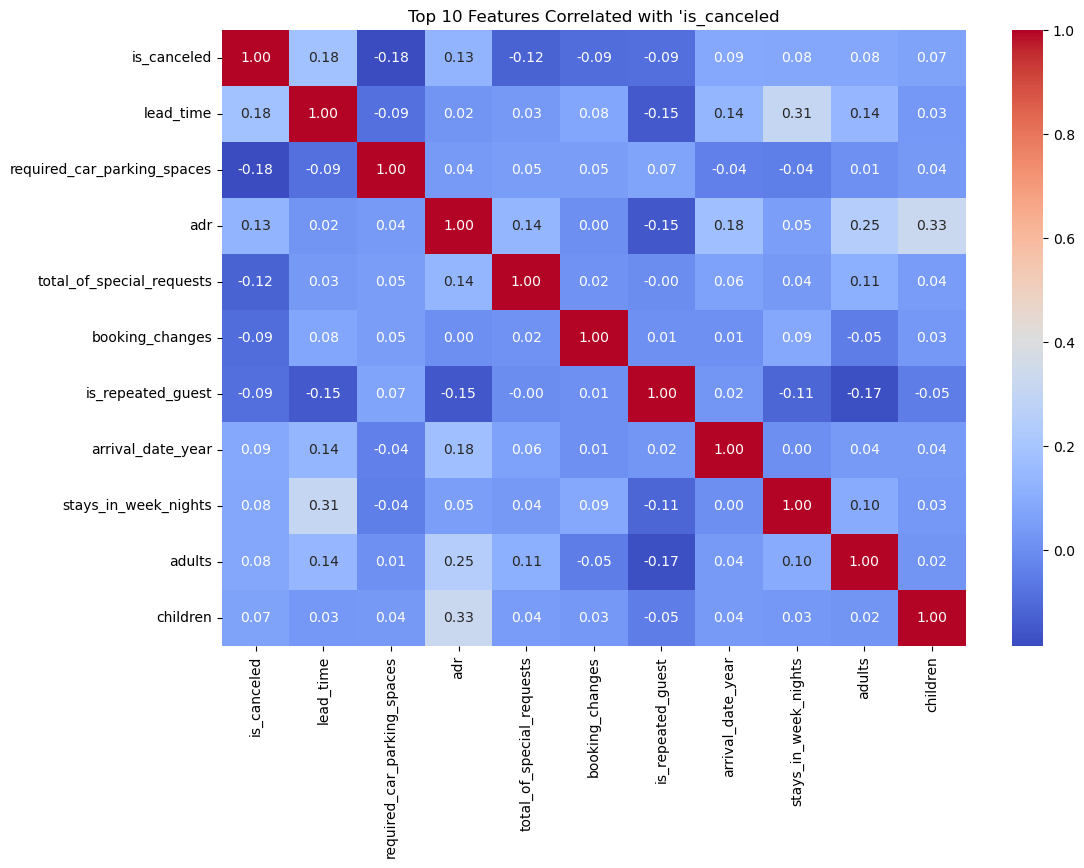

In [16]:
top_10_features_list = top_10_features.index.tolist()
subset_df = df[top_10_features_list]
subset_corr_matrix = subset_df.corr()
fig = plt.figure(figsize=(12, 8))
heat_map = sns.heatmap(subset_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top 10 Features Correlated with 'is_canceled")
plt.show()


## Check distribution of the target variable
Context:
- In classification problems, understanding the distribution of target variable is important. 
- If one class significantly outweighs the others, we call it class imbalance. 
- Class imbalance can result in model being biased toward the majority class

### For Barchart plotting
Hints:
1. Calculate the count of each category using the column from dataframe followed by value_counts method
2. Use the relevant function from seaborn to plot the barchart
3. Specify the index of the value_counts to plot on the x-axis (like category) and the values of the value_counts on the y-axis(like count of each category)
4. Set the x and y axis labels to describe the data
5. Give the plot an appropriate title describing the data
6. Show the plot with show method from matplotlib.pyplot

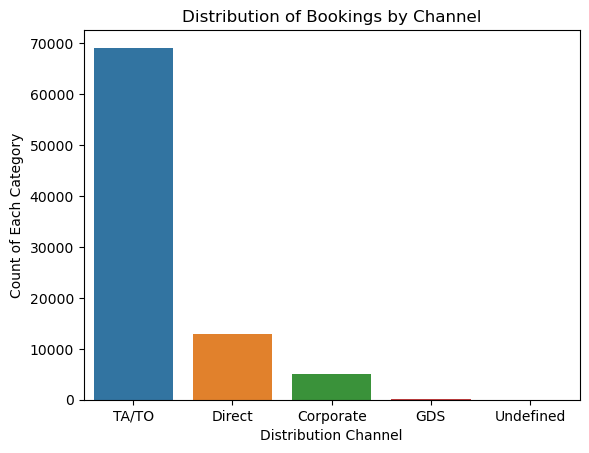

In [17]:

value_counts = df['distribution_channel'].value_counts()

cancellation_barplot = sns.barplot(x=value_counts.index, y=value_counts.values)

plt.xlabel('Distribution Channel')
plt.ylabel('Count of Each Category')
plt.title('Distribution of Bookings by Channel')
plt.show()


### 2.Months with maximum arrivals
Context:
- It allows us to understand which months had the most customers.

Hints:
1. Due to too many categories in the x-axis it may overlap. To prevent it the text can be rotated by an angle using xticks method from matplot library

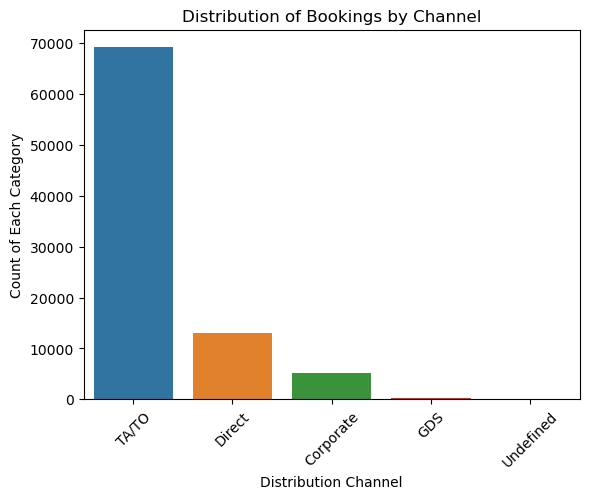

In [18]:
value_counts = df['distribution_channel'].value_counts()

arrivals_barplot = sns.barplot(x=value_counts.index, y=value_counts.values)

plt.xlabel('Distribution Channel')
plt.ylabel('Count of Each Category')
plt.title('Distribution of Bookings by Channel')
plt.xticks(rotation=45)
plt.show()

## Plot the arrival of customers as a time series

Context:
- Time series plot is a way to visualize data points over time
- Understanding and incorporating seasonality or trends into our decision tree model can enhance its predictive power. For instance, while classifying sales data, knowing the seasonal sales peaks and trends in customer behavior can guide the model to make more accurate predictions for different time periods.
- In our case, we're plotting the arrival date of customers to understand how trends and patterns change over time. By doing this, we can detect important patterns like seasonality, which helps us understand if there are recurring trends or cycles.

Hints:
1. Create the arrival_date by concatenating the columns arrival_date_year,arrival_date_month and arrival_day_of_month.
2. `+` operator can be used to concat the values from each column, add a string '-' between each column while concatting.(as dates are in the format dd-mm-yyyy). Assign this to a variable date
3. Convert the string variable date to datetime format using to_datetime method.
4. Assign date to a column 'arrival_date' of the dataframe.
5. Calculate the number of customers that arrived on each date by grouping the dataframe by the new column arrival_date using groupby method and follow it by size()
6. This arrival_count will be used to plot the timeseries
7. Specify the index of the arrival_count to plot on the x-axis and the values of the arrival_count on the y-axis
8. Use show method from matplotlib to display the plot

In [19]:
date = df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'] + '-' + df['arrival_date_day_of_month'].astype(str)

df['arrival_date'] = pd.to_datetime(date, format='%Y-%B-%d')

df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01


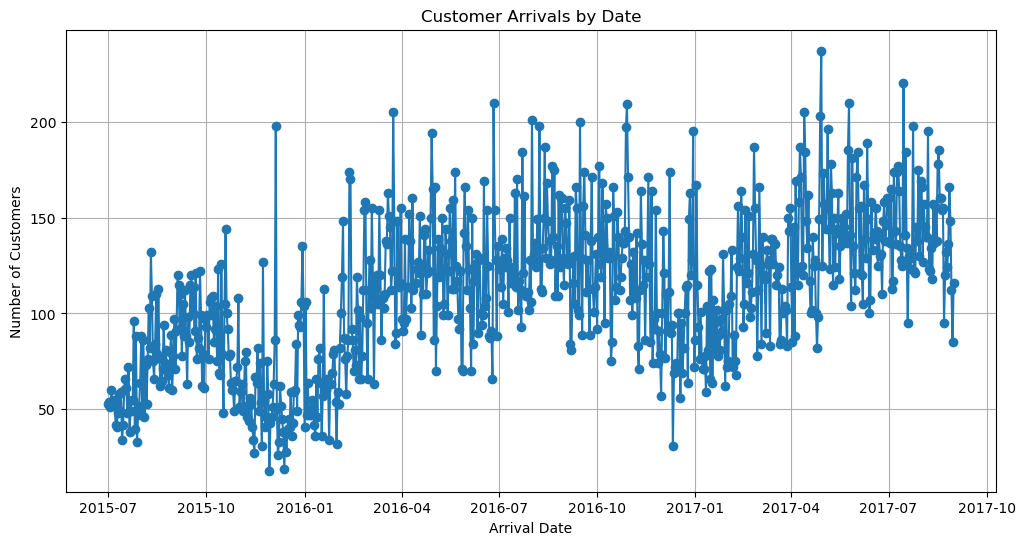

In [20]:
arrival_count = df.groupby('arrival_date').size()

plt.figure(figsize=(12, 6))
time_series = plt.plot(arrival_count.index, arrival_count.values, marker='o', linestyle='-')
plt.title('Customer Arrivals by Date')
plt.xlabel('Arrival Date')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

## Moving Average(also called Rolling Average)
Context:
1.  When we have lots of data points packed closely together, it can be difficult to spot any trend. To make things clearer, we use rolling average.
2. Rolling averages are useful for finding long-term trends, it replaces the current data point with the mean of the last n values making the plot smoother.
3. You can adjust how smooth you want the plot to be by changing the window size or 'n'. A bigger 'n' considers more data points, and a smaller 'n' gives a closer-to-original path.Try playing around with the value of n and see how the plot changes.

Hints:
1. Use the rolling method to set the window size, follow it by mean method to get the mean of the data points in the window size.
2. Plot the time series again but instead of using arrival_count on the y-axis use 'rolling_avg' calculated.

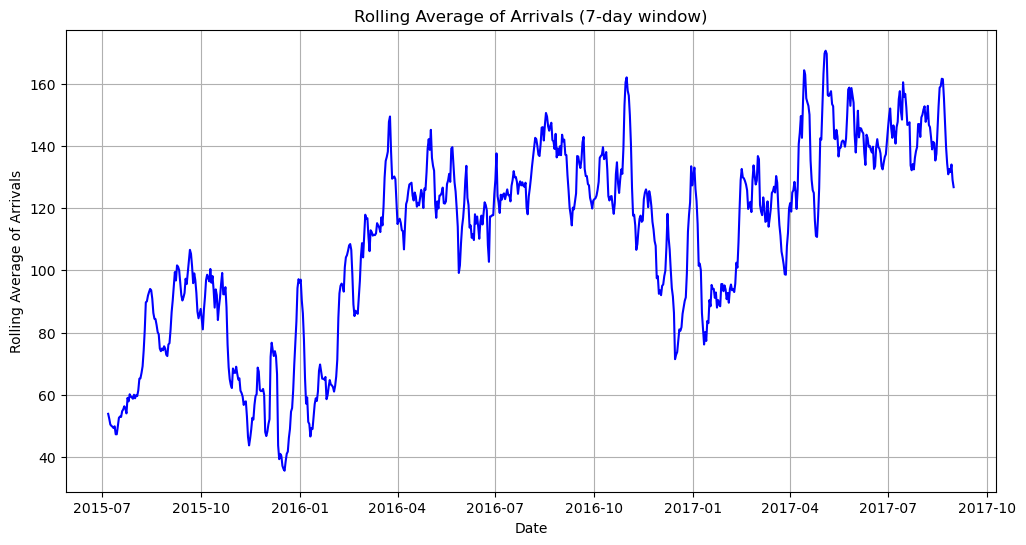

In [21]:
rolling_avg = arrival_count.rolling(window=7).mean() 

plt.figure(figsize=(12, 6))
time_series_smooth = plt.plot(rolling_avg.index, rolling_avg, linestyle='-', color='blue')
plt.title('Rolling Average of Arrivals (7-day window)')
plt.xlabel('Date')
plt.ylabel('Rolling Average of Arrivals')
plt.grid(True)
plt.show()

# Violin plot of numerical columns across different categories  of the target variable
Context:
- It is used for displaying the distribution of continuous numerical data(like lead_time,adr) across different categories of a feature.

Hints:
1. Use violinplot method from seaborn to create the violinplot, pass the x, y and data arguments
2. Use title method from matplotlib.pyplot to add the plot title
3. Call show method from matplotlib.pyplot to display the  plot

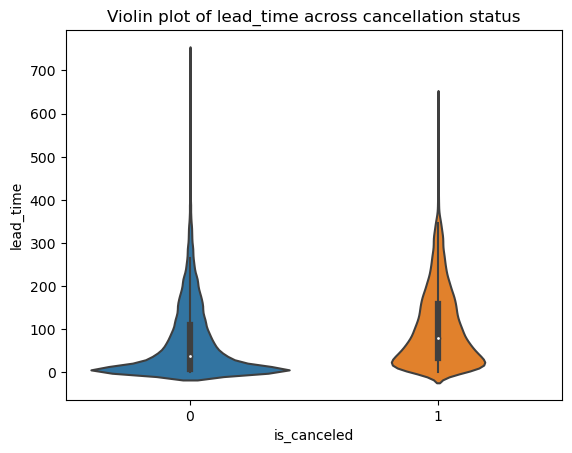

In [22]:
leadtime_violin_plot=sns.violinplot(x='is_canceled', y='lead_time', data=df)
plt.title('Violin plot of lead_time across cancellation status')
plt.show()

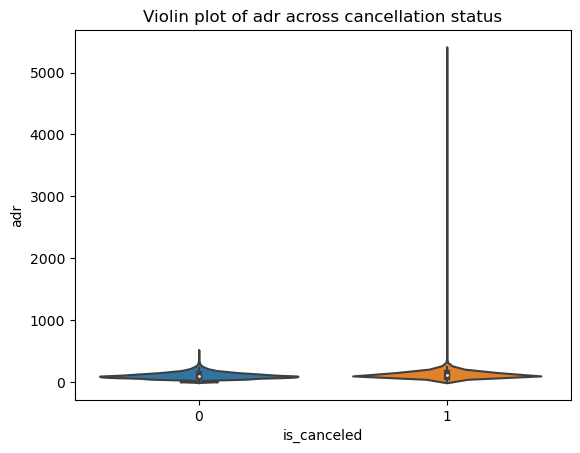

In [23]:
adr_violin_plot=sns.violinplot(x='is_canceled', y='adr', data=df)
plt.title('Violin plot of adr across cancellation status')
plt.show()

# Step 4 : Data cleaning and feature engineering from date column
Context:
### Handling Missing Values
- We identify columns with a high percentage of NULL values. Columns with excessive null values can negatively impact model performance, so we often choose to drop them.
- There is not a single fixed threshold percentage above which a column must be dropped, it depends on various factors.
- If the number of features are very less then every column is very important as dropping it will cause in a huge information loss. In this case the threshold can be a very high percentage.
- If the number of features are high and the concerned feature is not of much importance then the threshold can be a low percentage.
- In our case we can set the threshold to be 50%.

### Imputing Missing Values
- For columns with relatively low percentage of NULL values, we replace the missing entries with appropriate values. This ensures prevention of information loss.
- There are many ways to replace null values like random selection, mean, median, previous value and so on.These can be used for numerical columns.
- For categorical we can replace null by methods like - most frequent category(mode), previous category, new category that does not overlap with any of the existing categories(eg. column agent can be replaced with a number like -1 which has no chance of overlapping with another agent, for country "NA" can be used)

### Columns directly derived or related to target variable
- There are some features which are directly derived from the target variable and using these features will lead to overfitting.
- In our case the column reservation_status is directly related to target column is_canceled. Whenever reservation_status is "canceled" target variable is 0 and when reservation_status is "checked out" target variable is 1.
- This column must be dropped.
- After dropping reservation_status, we don't have any use for reservation_status_date because it was related to the reservation_status. Since we're dropping the status itself, the date doesn't serve any meaningful purpose anymore, so we can drop it too.
- Drop column arrival_date as it was created just to plot time series.


Hints:
1. In EDA we had calculated the count of null values in each column using isnull().sum(),to get the percentage just divide that by length of dataframe.
2. Based on the percentage of null values we can decide whether to drop the column or replace the null values.
3. You can drop the column using drop method
4. If the percentage is less, we can replace the null values using fillna method


In [24]:
null_value_percentage = df.isnull().sum()/len(df)
print(null_value_percentage)

hotel                             0.000000
is_canceled                       0.000000
lead_time                         0.000000
arrival_date_year                 0.000000
arrival_date_month                0.000000
arrival_date_week_number          0.000000
arrival_date_day_of_month         0.000000
stays_in_weekend_nights           0.000000
stays_in_week_nights              0.000000
adults                            0.000000
children                          0.000046
babies                            0.000000
meal                              0.000000
country                           0.005172
market_segment                    0.000000
distribution_channel              0.000000
is_repeated_guest                 0.000000
previous_cancellations            0.000000
previous_bookings_not_canceled    0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
deposit_type                      0.000000
agent      

In [25]:
df['country'] = df['country'].replace("NA")
df['agent'] = df['agent'].replace(-1)

median_value = df['children'].median()
df['children'] = df['children'].fillna(median_value)

In [26]:
columns_to_drop = ['company','reservation_status','arrival_date','arrival_date_week_number','reservation_status_date']
for col in columns_to_drop:
    df = df.drop([col], axis=1)
df.head(5)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


# Step 5 Encoding
Context:
- Encoding is the process of converting categorical data (data that represents categories, labels, or classes) into numerical values, which can be used by machine learning algorithms.
- There are two main types of encoding - one hot encoding and label encoding
- One-hot encoding should be used on columns which have nominal variables i.e. columns where categories are all equally important (eg. Gender- Both the genders male and female are considered equal as there is no hierarchy between them). In our case country can be considered nominal as customer from every country is the same and there is no bias.
- Label encoding should be used on ordinal variables i.e. columns where the categories have a hierarchy (eg. Grades- Grade A is considered to be superior to grade D). In our case room_type can be considered ordinal as AC room has higher hierarchy than normal room.

### Cardinality
- Cardinality indicates how many unique elements are present in an attribute.
- High cardinality is likely to cause dimensionality issues, overfitting, and provide little useful information for both visualization and modeling
- So we recommend dropping it from the analysis
- If the number of features are very less then every column is very important as dropping it will cause in a huge information loss. In this case the threshold can be a very high percentage.
- If the number of features are high and the concerned feature is not of much importance then the threshold can be a low percentage.
- In our case  we can set the threshold to be 30%.
- Dont condider cardinality for continuous numerical columns as they will not be encoded

Hints:
1. To get number of unique values in each column use the function nunique method
2. To check if it is high or not you can divide it by the number of rows(len(df)) to get the proportion.
3. One hot encoding can be done using get_dummies method
4. Label encoding can be done using LabelEncoder method
5. Nominal columns to one hot encode: 'arrival_date_year','arrival_date_month','arrival_date_day_of_month','hotel','meal','market_segment','country','distribution_channel','deposit_type','agent','customer_type'
6. Ordinal columns to label encode:'reserved_room_type', 'assigned_room_type' 



In [27]:
unique_counts = df.nunique()
proportion = unique_counts/len(df)
print(proportion)

hotel                             0.000023
is_canceled                       0.000023
lead_time                         0.005481
arrival_date_year                 0.000034
arrival_date_month                0.000137
arrival_date_day_of_month         0.000355
stays_in_weekend_nights           0.000195
stays_in_week_nights              0.000400
adults                            0.000160
children                          0.000057
babies                            0.000057
meal                              0.000057
country                           0.002025
market_segment                    0.000092
distribution_channel              0.000057
is_repeated_guest                 0.000023
previous_cancellations            0.000172
previous_bookings_not_canceled    0.000835
reserved_room_type                0.000114
assigned_room_type                0.000137
booking_changes                   0.000240
deposit_type                      0.000034
agent                             0.003810
days_in_wai

In [28]:
#one hot
nominal_columns = ['arrival_date_year','arrival_date_month','arrival_date_day_of_month','hotel','meal','market_segment','country','distribution_channel','deposit_type','agent','customer_type']
df = pd.get_dummies(df, columns=nominal_columns, prefix=nominal_columns, drop_first=True)
df.head(5)

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_year_2016,arrival_date_year_2017,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,arrival_date_day_of_month_2,arrival_date_day_of_month_3,arrival_date_day_of_month_4,arrival_date_day_of_month_5,arrival_date_day_of_month_6,arrival_date_day_of_month_7,arrival_date_day_of_month_8,arrival_date_day_of_month_9,arrival_date_day_of_month_10,arrival_date_day_of_month_11,arrival_date_day_of_month_12,arrival_date_day_of_month_13,arrival_date_day_of_month_14,arrival_date_day_of_month_15,arrival_date_day_of_month_16,arrival_date_day_of_month_17,arrival_date_day_of_month_18,arrival_date_day_of_month_19,arrival_date_day_of_month_20,arrival_date_day_of_month_21,arrival_date_day_of_month_22,arrival_date_day_of_month_23,arrival_date_day_of_month_24,arrival_date_day_of_month_25,arrival_date_day_of_month_26,arrival_date_day_of_month_27,arrival_date_day_of_month_28,arrival_date_day_of_month_29,arrival_date_day_of_month_30,arrival_date_day_of_month_31,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BDI,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BHS,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_BWA,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DJI,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_GUY,country_HKG,country_HND,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KIR,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LCA,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MCO,country_MDG,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MRT,country_MUS,country_MWI,country_MYS,country_MYT,country_NAM,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,ag

In [29]:
#label 
ordinal_columns = ['reserved_room_type', 'assigned_room_type']

label_encoder = LabelEncoder()

for column in ordinal_columns:
    df[column] = label_encoder.fit_transform(df[column])
df.head(5)

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_year_2016,arrival_date_year_2017,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,arrival_date_day_of_month_2,arrival_date_day_of_month_3,arrival_date_day_of_month_4,arrival_date_day_of_month_5,arrival_date_day_of_month_6,arrival_date_day_of_month_7,arrival_date_day_of_month_8,arrival_date_day_of_month_9,arrival_date_day_of_month_10,arrival_date_day_of_month_11,arrival_date_day_of_month_12,arrival_date_day_of_month_13,arrival_date_day_of_month_14,arrival_date_day_of_month_15,arrival_date_day_of_month_16,arrival_date_day_of_month_17,arrival_date_day_of_month_18,arrival_date_day_of_month_19,arrival_date_day_of_month_20,arrival_date_day_of_month_21,arrival_date_day_of_month_22,arrival_date_day_of_month_23,arrival_date_day_of_month_24,arrival_date_day_of_month_25,arrival_date_day_of_month_26,arrival_date_day_of_month_27,arrival_date_day_of_month_28,arrival_date_day_of_month_29,arrival_date_day_of_month_30,arrival_date_day_of_month_31,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BDI,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BHS,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_BWA,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DJI,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_GUY,country_HKG,country_HND,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KIR,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LCA,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MCO,country_MDG,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MRT,country_MUS,country_MWI,country_MYS,country_MYT,country_NAM,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,ag

# Step 6 Transformation
Context:
- Some ML models like linear and logistic regression assume that the variables are normally distributed.
- Their accuracy would be affected if the variables are not normally distributed hence we perform transformation.
- There are many ways to transform like : log transformation, reciprocal transformation, square root transformation,exponential transformation, boxcox transformation.

### Skewness
- The type of transformation to be used is dependent on the skewness of the data.
- Skewness is a measure of how symmetric data is. Symmetric data(eg normal distribution) has zero skewness.
- Positive skewness(Right skew): It has skewness value > 0. The distribution is concentrated on the left.
- Negative skewness(Left skew): It has skewness value < 0. The distribution is concentrated on the right.

### Transformations
- Log Transformation: Use when data is right-skewed
- Reciprocal Transformation: Appropriate for left-skewed data 
- Square Root Transformation: Useful for reducing the impact of outliers in right-skewed data.
- Exponential Transformation: Useful for making left-skewed data more symmetric.
- Box-Cox Transformation: Versatile; it finds the best transformation (including log, square root, etc.) for your data to minimize skewness.

Hints:
1. To check if the data is skewed you can calculate skew using the relevant function from stats library.
2. Right skewed data(skewness>0) can be transformed using np.log() and passing the column that we want to transform, the column has to be continuous numerical column
3. To see the change in distribution before and after the trasnformation we can compare the histograms 

Hints(for plotting histogram):
1. Use the relevant function from seaborn to plot the histogram
2. For the dataframe, use the dataframe variable containing your data
3. Specify the column to plot on the x-axis 
4. Pick a color for the histogram like 'skyblue'
5. Set the number of bins
6. Give the plot an appropriate title describing the data
7. Set the x and y axis labels to describe the data
8. As there are more than one column that are numerical we can use a for loop to loop through them.

Skew of lead_time :  1.4317491974651346
Skew of adr :  10.921259281301458


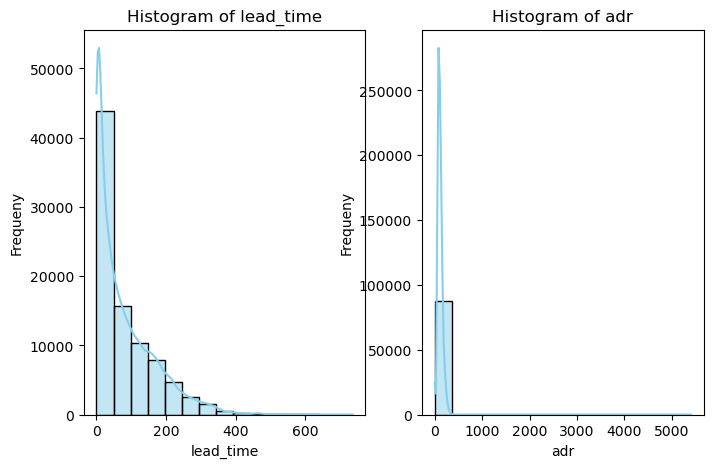

In [30]:
numerical_columns = ['lead_time','adr']
i = 1
fig = plt.figure(figsize=(8, 5))
for column in numerical_columns:
    column_data = df[column]
    skewness = stats.skew(column_data)
    print(f"Skew of {column} : ",skewness)
    plt.subplot(1, 2, i)
    h = sns.histplot(df, x=column, kde=True, color='skyblue', bins=15)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequeny')
    i = i+1


/opt/conda/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


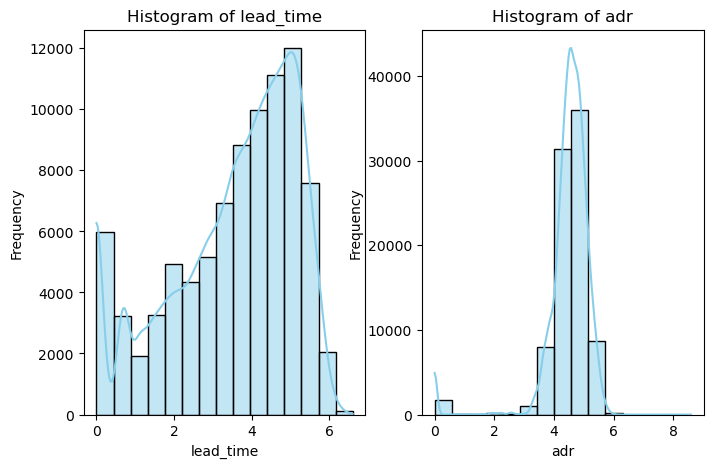

In [32]:
transformed_df = pd.DataFrame()
i = 1
fig2 = plt.figure(figsize=(8,5))
for column in numerical_columns:
    transformed_df[column]=np.log(df[column]+1)
    column_data = transformed_df[column]
    skewness = stats.skew(column_data)
    plt.subplot(1, 2, i)
    h1 = sns.histplot(transformed_df, x=column, kde=True, color='skyblue', bins=15)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    i = i+1

# Step 7 Scaling
Context:
- Scaling is required in machine learning to ensure that features with different units or scales do not dominate the learning process
- It is not necessary to apply standardization to categorical features, so we can create a list numerical_features that contains the list of all numerical columns and apply standardization only to them.

Hints:
1. Create a scaler object using MinMaxScaler()
2. Loop through the numerical_columns list to fit and transform the numerical columns using the function fit_transform
3. After getting the scaled data use it to replace the original data in the numerical columns

In [33]:
scaler = MinMaxScaler()
numerical_columns = ['lead_time','adr']
for col in numerical_columns:
    numerical_data = transformed_df[col].values.reshape(-1, 1)
    X_scaled = scaler.fit_transform(numerical_data)
    transformed_df[col] = X_scaled
transformed_df.head(5)

,lead_time,adr
0,0.883976,0.000000
1,1.000000,0.000000
2,0.314879,0.503905
3,0.399618,0.503905
4,0.410066,0.534668
